In [1]:
from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("TrafficAccidentBigData") \
    .master("local[*]") \
    .getOrCreate()

print("Spark Version:", spark.version)

Spark Version: 4.2.0


In [3]:
import os

print(os.listdir("."))

['.ipynb_checkpoints', 'archive.ics.uci.edu', 'Assam flood Analytics.ipynb', 'Assam flood Project', 'casualty.csv', 'collision.csv', 'rainfall_tel_hr_cwc_as_2021_2025.csv', 'Traffic_Accident_BigData_Analysis.ipynb', 'vehicles.csv']


In [4]:
spark.read.csv("vehicles.csv", header=True, inferSchema=True)

DataFrame[collision_index: string, collision_year: int, collision_ref_no: string, vehicle_reference: int, vehicle_type: int, towing_and_articulation: int, vehicle_manoeuvre_historic: int, vehicle_manoeuvre: int, vehicle_direction_from: int, vehicle_direction_to: int, vehicle_location_restricted_lane_historic: int, vehicle_location_restricted_lane: int, junction_location: int, skidding_and_overturning: int, hit_object_in_carriageway: int, vehicle_leaving_carriageway: int, hit_object_off_carriageway: int, first_point_of_impact: int, vehicle_left_hand_drive: int, journey_purpose_of_driver_historic: int, journey_purpose_of_driver: int, sex_of_driver: int, age_of_driver: int, age_band_of_driver: int, engine_capacity_cc: int, propulsion_code: int, age_of_vehicle: int, generic_make_model: string, driver_imd_decile: int, lsoa_of_driver: string, escooter_flag: int, driver_distance_banding: int]

In [6]:
spark.read.csv("collision.csv", header=True, inferSchema=True)

DataFrame[collision_index: string, collision_year: int, collision_ref_no: string, location_easting_osgr: int, location_northing_osgr: int, longitude: double, latitude: double, police_force: int, collision_severity: int, number_of_vehicles: int, number_of_casualties: int, date: string, day_of_week: int, time: timestamp, local_authority_district: int, local_authority_ons_district: string, local_authority_highway: string, local_authority_highway_current: string, first_road_class: int, first_road_number: int, road_type: int, speed_limit: int, junction_detail_historic: int, junction_detail: int, junction_control: int, second_road_class: int, second_road_number: int, pedestrian_crossing_human_control_historic: int, pedestrian_crossing_physical_facilities_historic: int, pedestrian_crossing: int, light_conditions: int, weather_conditions: int, road_surface_conditions: int, special_conditions_at_site: int, carriageway_hazards_historic: int, carriageway_hazards: int, urban_or_rural_area: int, di

In [10]:
spark.read.csv("casulaity.csv", header=True, inferSchema=True)

DataFrame[collision_index: string, collision_year: int, collision_ref_no: string, vehicle_reference: int, casualty_reference: int, casualty_class: int, sex_of_casualty: int, age_of_casualty: int, age_band_of_casualty: int, casualty_severity: int, pedestrian_location: int, pedestrian_movement: int, car_passenger: int, bus_or_coach_passenger: int, pedestrian_road_maintenance_worker: int, casualty_type: int, casualty_imd_decile: int, lsoa_of_casualty: string, enhanced_casualty_severity: int, casualty_injury_based: int, casualty_adjusted_severity_serious: double, casualty_adjusted_severity_slight: double, casualty_distance_banding: int]

In [13]:
collisions = spark.read.csv(
    "collision.csv",
    header=True,
    inferSchema=True
)

print("Collisions loaded successfully!")
print("Rows:", collisions.count())
print("Columns:", len(collisions.columns))

Collisions loaded successfully!
Rows: 101525
Columns: 44


In [14]:
collisions.printSchema()

root
 |-- collision_index: string (nullable = true)
 |-- collision_year: integer (nullable = true)
 |-- collision_ref_no: string (nullable = true)
 |-- location_easting_osgr: integer (nullable = true)
 |-- location_northing_osgr: integer (nullable = true)
 |-- longitude: double (nullable = true)
 |-- latitude: double (nullable = true)
 |-- police_force: integer (nullable = true)
 |-- collision_severity: integer (nullable = true)
 |-- number_of_vehicles: integer (nullable = true)
 |-- number_of_casualties: integer (nullable = true)
 |-- date: string (nullable = true)
 |-- day_of_week: integer (nullable = true)
 |-- time: timestamp (nullable = true)
 |-- local_authority_district: integer (nullable = true)
 |-- local_authority_ons_district: string (nullable = true)
 |-- local_authority_highway: string (nullable = true)
 |-- local_authority_highway_current: string (nullable = true)
 |-- first_road_class: integer (nullable = true)
 |-- first_road_number: integer (nullable = true)
 |-- road_

In [15]:
collisions.show(5, truncate=False)

+---------------+--------------+----------------+---------------------+----------------------+---------+--------+------------+------------------+------------------+--------------------+----------+-----------+-------------------+------------------------+----------------------------+-----------------------+-------------------------------+----------------+-----------------+---------+-----------+------------------------+---------------+----------------+-----------------+------------------+------------------------------------------+------------------------------------------------+-------------------+----------------+------------------+-----------------------+--------------------------+----------------------------+-------------------+-------------------+-------------------------------------------+---------------+-------------------------+---------------------------+----------------------+-----------------------------------+----------------------------------+
|collision_index|collision_year|c

In [16]:
vehicles = spark.read.csv(
    "vehicles.csv",
    header=True,
    inferSchema=True
)

print("Vehicles loaded successfully!")
print("Rows:", vehicles.count())
print("Columns:", len(vehicles.columns))

Vehicles loaded successfully!
Rows: 183948
Columns: 32


In [17]:
vehicles.printSchema()

root
 |-- collision_index: string (nullable = true)
 |-- collision_year: integer (nullable = true)
 |-- collision_ref_no: string (nullable = true)
 |-- vehicle_reference: integer (nullable = true)
 |-- vehicle_type: integer (nullable = true)
 |-- towing_and_articulation: integer (nullable = true)
 |-- vehicle_manoeuvre_historic: integer (nullable = true)
 |-- vehicle_manoeuvre: integer (nullable = true)
 |-- vehicle_direction_from: integer (nullable = true)
 |-- vehicle_direction_to: integer (nullable = true)
 |-- vehicle_location_restricted_lane_historic: integer (nullable = true)
 |-- vehicle_location_restricted_lane: integer (nullable = true)
 |-- junction_location: integer (nullable = true)
 |-- skidding_and_overturning: integer (nullable = true)
 |-- hit_object_in_carriageway: integer (nullable = true)
 |-- vehicle_leaving_carriageway: integer (nullable = true)
 |-- hit_object_off_carriageway: integer (nullable = true)
 |-- first_point_of_impact: integer (nullable = true)
 |-- veh

In [18]:
vehicles.show(5, truncate=False)

+---------------+--------------+----------------+-----------------+------------+-----------------------+--------------------------+-----------------+----------------------+--------------------+-----------------------------------------+--------------------------------+-----------------+------------------------+-------------------------+---------------------------+--------------------------+---------------------+-----------------------+----------------------------------+-------------------------+-------------+-------------+------------------+------------------+---------------+--------------+-----------------------+-----------------+--------------+-------------+-----------------------+
|collision_index|collision_year|collision_ref_no|vehicle_reference|vehicle_type|towing_and_articulation|vehicle_manoeuvre_historic|vehicle_manoeuvre|vehicle_direction_from|vehicle_direction_to|vehicle_location_restricted_lane_historic|vehicle_location_restricted_lane|junction_location|skidding_and_overturni

In [20]:
casualties = spark.read.csv(
    "casulaity.csv",
    header=True,
    inferSchema=True
)

print("Casualties loaded successfully!")
print("Rows:", casualties.count())
print("Columns:", len(casualties.columns))

Casualties loaded successfully!
Rows: 127883
Columns: 23


In [21]:
casualties.printSchema()

root
 |-- collision_index: string (nullable = true)
 |-- collision_year: integer (nullable = true)
 |-- collision_ref_no: string (nullable = true)
 |-- vehicle_reference: integer (nullable = true)
 |-- casualty_reference: integer (nullable = true)
 |-- casualty_class: integer (nullable = true)
 |-- sex_of_casualty: integer (nullable = true)
 |-- age_of_casualty: integer (nullable = true)
 |-- age_band_of_casualty: integer (nullable = true)
 |-- casualty_severity: integer (nullable = true)
 |-- pedestrian_location: integer (nullable = true)
 |-- pedestrian_movement: integer (nullable = true)
 |-- car_passenger: integer (nullable = true)
 |-- bus_or_coach_passenger: integer (nullable = true)
 |-- pedestrian_road_maintenance_worker: integer (nullable = true)
 |-- casualty_type: integer (nullable = true)
 |-- casualty_imd_decile: integer (nullable = true)
 |-- lsoa_of_casualty: string (nullable = true)
 |-- enhanced_casualty_severity: integer (nullable = true)
 |-- casualty_injury_based: i

In [22]:
casualties.show(5, truncate=False)

+---------------+--------------+----------------+-----------------+------------------+--------------+---------------+---------------+--------------------+-----------------+-------------------+-------------------+-------------+----------------------+----------------------------------+-------------+-------------------+----------------+--------------------------+---------------------+----------------------------------+---------------------------------+-------------------------+
|collision_index|collision_year|collision_ref_no|vehicle_reference|casualty_reference|casualty_class|sex_of_casualty|age_of_casualty|age_band_of_casualty|casualty_severity|pedestrian_location|pedestrian_movement|car_passenger|bus_or_coach_passenger|pedestrian_road_maintenance_worker|casualty_type|casualty_imd_decile|lsoa_of_casualty|enhanced_casualty_severity|casualty_injury_based|casualty_adjusted_severity_serious|casualty_adjusted_severity_slight|casualty_distance_banding|
+---------------+--------------+--------

In [23]:
from pyspark.sql.functions import col, sum

collision_missing = collisions.select([
    sum(col(c).isNull().cast("int")).alias(c)
    for c in collisions.columns
])

collision_missing.show(truncate=False)

+---------------+--------------+----------------+---------------------+----------------------+---------+--------+------------+------------------+------------------+--------------------+----+-----------+----+------------------------+----------------------------+-----------------------+-------------------------------+----------------+-----------------+---------+-----------+------------------------+---------------+----------------+-----------------+------------------+------------------------------------------+------------------------------------------------+-------------------+----------------+------------------+-----------------------+--------------------------+----------------------------+-------------------+-------------------+-------------------------------------------+---------------+-------------------------+---------------------------+----------------------+-----------------------------------+----------------------------------+
|collision_index|collision_year|collision_ref_no|locat

In [24]:
vehicle_missing = vehicles.select([
    sum(col(c).isNull().cast("int")).alias(c)
    for c in vehicles.columns
])

vehicle_missing.show(truncate=False)

+---------------+--------------+----------------+-----------------+------------+-----------------------+--------------------------+-----------------+----------------------+--------------------+-----------------------------------------+--------------------------------+-----------------+------------------------+-------------------------+---------------------------+--------------------------+---------------------+-----------------------+----------------------------------+-------------------------+-------------+-------------+------------------+------------------+---------------+--------------+------------------+-----------------+--------------+-------------+-----------------------+
|collision_index|collision_year|collision_ref_no|vehicle_reference|vehicle_type|towing_and_articulation|vehicle_manoeuvre_historic|vehicle_manoeuvre|vehicle_direction_from|vehicle_direction_to|vehicle_location_restricted_lane_historic|vehicle_location_restricted_lane|junction_location|skidding_and_overturning|hi

In [25]:
casualty_missing = casualties.select([
    sum(col(c).isNull().cast("int")).alias(c)
    for c in casualties.columns
])

casualty_missing.show(truncate=False)

+---------------+--------------+----------------+-----------------+------------------+--------------+---------------+---------------+--------------------+-----------------+-------------------+-------------------+-------------+----------------------+----------------------------------+-------------+-------------------+----------------+--------------------------+---------------------+----------------------------------+---------------------------------+-------------------------+
|collision_index|collision_year|collision_ref_no|vehicle_reference|casualty_reference|casualty_class|sex_of_casualty|age_of_casualty|age_band_of_casualty|casualty_severity|pedestrian_location|pedestrian_movement|car_passenger|bus_or_coach_passenger|pedestrian_road_maintenance_worker|casualty_type|casualty_imd_decile|lsoa_of_casualty|enhanced_casualty_severity|casualty_injury_based|casualty_adjusted_severity_serious|casualty_adjusted_severity_slight|casualty_distance_banding|
+---------------+--------------+--------

In [26]:
from pyspark.sql.functions import col, min, max

for c in collisions.columns:
    if dict(collisions.dtypes)[c] in ["int", "bigint", "double", "float"]:
        print(f"\n--- {c} ---")
        collisions.select(
            min(col(c)).alias("min"),
            max(col(c)).alias("max")
        ).show()


--- collision_year ---
+----+----+
| min| max|
+----+----+
|2025|2025|
+----+----+


--- location_easting_osgr ---
+-----+------+
|  min|   max|
+-----+------+
|71253|655126|
+-----+------+


--- location_northing_osgr ---
+-----+-------+
|  min|    max|
+-----+-------+
|10237|1162591|
+-----+-------+


--- longitude ---
+--------+-------+
|     min|    max|
+--------+-------+
|-7.41772|1.75559|
+--------+-------+


--- latitude ---
+--------+--------+
|     min|     max|
+--------+--------+
|49.91253|60.34525|
+--------+--------+


--- police_force ---
+---+---+
|min|max|
+---+---+
|  1| 99|
+---+---+


--- collision_severity ---
+---+---+
|min|max|
+---+---+
|  1|  3|
+---+---+


--- number_of_vehicles ---
+---+---+
|min|max|
+---+---+
|  1| 17|
+---+---+


--- number_of_casualties ---
+---+---+
|min|max|
+---+---+
|  1|142|
+---+---+


--- day_of_week ---
+---+---+
|min|max|
+---+---+
|  1|  7|
+---+---+


--- local_authority_district ---
+---+---+
|min|max|
+---+---+
| -1| -1|
+--

In [27]:
for c in vehicles.columns:
    if dict(vehicles.dtypes)[c] in ["int", "bigint", "double", "float"]:
        print(f"\n--- {c} ---")
        vehicles.select(
            min(col(c)).alias("min"),
            max(col(c)).alias("max")
        ).show()


--- collision_year ---
+----+----+
| min| max|
+----+----+
|2025|2025|
+----+----+


--- vehicle_reference ---
+---+---+
|min|max|
+---+---+
|  1|291|
+---+---+


--- vehicle_type ---
+---+---+
|min|max|
+---+---+
| -1| 99|
+---+---+


--- towing_and_articulation ---
+---+---+
|min|max|
+---+---+
| -1|  9|
+---+---+


--- vehicle_manoeuvre_historic ---
+---+---+
|min|max|
+---+---+
| -1| 99|
+---+---+


--- vehicle_manoeuvre ---
+---+---+
|min|max|
+---+---+
| -1| 99|
+---+---+


--- vehicle_direction_from ---
+---+---+
|min|max|
+---+---+
| -1|  9|
+---+---+


--- vehicle_direction_to ---
+---+---+
|min|max|
+---+---+
| -1|  9|
+---+---+


--- vehicle_location_restricted_lane_historic ---
+---+---+
|min|max|
+---+---+
| -1| 99|
+---+---+


--- vehicle_location_restricted_lane ---
+---+---+
|min|max|
+---+---+
| -1| 99|
+---+---+


--- junction_location ---
+---+---+
|min|max|
+---+---+
| -1|  9|
+---+---+


--- skidding_and_overturning ---
+---+---+
|min|max|
+---+---+
| -1|  9|
+---

In [28]:
for c in casualties.columns:
    if dict(casualties.dtypes)[c] in ["int", "bigint", "double", "float"]:
        print(f"\n--- {c} ---")
        casualties.select(
            min(col(c)).alias("min"),
            max(col(c)).alias("max")
        ).show()


--- collision_year ---
+----+----+
| min| max|
+----+----+
|2025|2025|
+----+----+


--- vehicle_reference ---
+---+---+
|min|max|
+---+---+
|  1|291|
+---+---+


--- casualty_reference ---
+---+---+
|min|max|
+---+---+
|  1|142|
+---+---+


--- casualty_class ---
+---+---+
|min|max|
+---+---+
|  1|  3|
+---+---+


--- sex_of_casualty ---
+---+---+
|min|max|
+---+---+
| -1|  9|
+---+---+


--- age_of_casualty ---
+---+---+
|min|max|
+---+---+
| -1|105|
+---+---+


--- age_band_of_casualty ---
+---+---+
|min|max|
+---+---+
| -1| 11|
+---+---+


--- casualty_severity ---
+---+---+
|min|max|
+---+---+
|  1|  3|
+---+---+


--- pedestrian_location ---
+---+---+
|min|max|
+---+---+
| -1| 10|
+---+---+


--- pedestrian_movement ---
+---+---+
|min|max|
+---+---+
| -1|  9|
+---+---+


--- car_passenger ---
+---+---+
|min|max|
+---+---+
| -1|  9|
+---+---+


--- bus_or_coach_passenger ---
+---+---+
|min|max|
+---+---+
| -1|  9|
+---+---+


--- pedestrian_road_maintenance_worker ---
+---+---+
|

In [30]:
from pyspark.sql.functions import col

numeric_types = ["int", "bigint", "double", "float", "long", "short"]

for c, dtype in collisions.dtypes:
    if dtype in numeric_types:
        count = collisions.filter(col(c) == -1).count()
        if count > 0:
            print(f"{c}: {count}")

local_authority_district: 101525
first_road_class: 6
first_road_number: 6
junction_detail_historic: 87871
junction_detail: 6701
junction_control: 44487
second_road_class: 171
second_road_number: 25105
pedestrian_crossing_human_control_historic: 87852
pedestrian_crossing_physical_facilities_historic: 87851
pedestrian_crossing: 6527
light_conditions: 16
road_surface_conditions: 634
special_conditions_at_site: 87858
carriageway_hazards_historic: 87852
carriageway_hazards: 5346
trunk_road_flag: 7108
enhanced_severity_collision: 13677


In [31]:
numeric_types = ["int", "bigint", "double", "float", "long", "short"]

for c, dtype in vehicles.dtypes:
    if dtype in numeric_types:
        count = vehicles.filter(col(c) == -1).count()
        if count > 0:
            print(f"{c}: {count}")

vehicle_type: 1478
towing_and_articulation: 1865
vehicle_manoeuvre_historic: 161547
vehicle_manoeuvre: 5198
vehicle_direction_from: 6832
vehicle_direction_to: 6865
vehicle_location_restricted_lane_historic: 159544
vehicle_location_restricted_lane: 5368
junction_location: 2456
skidding_and_overturning: 5435
hit_object_in_carriageway: 3113
vehicle_leaving_carriageway: 5378
hit_object_off_carriageway: 3067
first_point_of_impact: 3764
vehicle_left_hand_drive: 196
journey_purpose_of_driver_historic: 161056
journey_purpose_of_driver: 4395
sex_of_driver: 4307
age_of_driver: 28262
age_band_of_driver: 28262
engine_capacity_cc: 44869
propulsion_code: 38869
age_of_vehicle: 183948
driver_imd_decile: 41539
driver_distance_banding: 41539


In [32]:
numeric_types = ["int", "bigint", "double", "float", "long", "short"]

for c, dtype in casualties.dtypes:
    if dtype in numeric_types:
        count = casualties.filter(col(c) == -1).count()
        if count > 0:
            print(f"{c}: {count}")

sex_of_casualty: 1320
age_of_casualty: 2741
age_band_of_casualty: 2741
pedestrian_location: 43
pedestrian_movement: 41
car_passenger: 500
bus_or_coach_passenger: 282
pedestrian_road_maintenance_worker: 17457
casualty_type: 1229
casualty_imd_decile: 14663
enhanced_casualty_severity: 17394
casualty_distance_banding: 14663


In [33]:
print(
    "Collision duplicate rows:",
    collisions.count() - collisions.dropDuplicates().count()
)

Collision duplicate rows: 0


In [34]:
print(
    "Vehicle duplicate rows:",
    vehicles.count() - vehicles.dropDuplicates().count()
)

Vehicle duplicate rows: 0


In [35]:
print(
    "Casualty duplicate rows:",
    casualties.count() - casualties.dropDuplicates().count()
)

Casualty duplicate rows: 0


In [36]:
from pyspark.sql.functions import when, col

collision_clean = collisions

for c, dtype in collisions.dtypes:
    if dtype in ["int", "bigint", "double", "float", "long", "short"]:
        collision_clean = collision_clean.withColumn(
            c,
            when(col(c) == -1, None).otherwise(col(c))
        )

print("Collision preprocessing completed.")

Collision preprocessing completed.


In [37]:
collision_clean.show(5, truncate=False)

+---------------+--------------+----------------+---------------------+----------------------+---------+--------+------------+------------------+------------------+--------------------+----------+-----------+-------------------+------------------------+----------------------------+-----------------------+-------------------------------+----------------+-----------------+---------+-----------+------------------------+---------------+----------------+-----------------+------------------+------------------------------------------+------------------------------------------------+-------------------+----------------+------------------+-----------------------+--------------------------+----------------------------+-------------------+-------------------+-------------------------------------------+---------------+-------------------------+---------------------------+----------------------+-----------------------------------+----------------------------------+
|collision_index|collision_year|c

In [38]:
vehicle_clean = vehicles

for c, dtype in vehicles.dtypes:
    if dtype in ["int", "bigint", "double", "float", "long", "short"]:
        vehicle_clean = vehicle_clean.withColumn(
            c,
            when(col(c) == -1, None).otherwise(col(c))
        )

print("Vehicle preprocessing completed.")

Vehicle preprocessing completed.


In [39]:
vehicle_clean.show(5, truncate=False)

+---------------+--------------+----------------+-----------------+------------+-----------------------+--------------------------+-----------------+----------------------+--------------------+-----------------------------------------+--------------------------------+-----------------+------------------------+-------------------------+---------------------------+--------------------------+---------------------+-----------------------+----------------------------------+-------------------------+-------------+-------------+------------------+------------------+---------------+--------------+-----------------------+-----------------+--------------+-------------+-----------------------+
|collision_index|collision_year|collision_ref_no|vehicle_reference|vehicle_type|towing_and_articulation|vehicle_manoeuvre_historic|vehicle_manoeuvre|vehicle_direction_from|vehicle_direction_to|vehicle_location_restricted_lane_historic|vehicle_location_restricted_lane|junction_location|skidding_and_overturni

In [40]:
casualty_clean = casualties

for c, dtype in casualties.dtypes:
    if dtype in ["int", "bigint", "double", "float", "long", "short"]:
        casualty_clean = casualty_clean.withColumn(
            c,
            when(col(c) == -1, None).otherwise(col(c))
        )

print("Casualty preprocessing completed.")

Casualty preprocessing completed.


In [41]:
casualty_clean.show(5, truncate=False)

+---------------+--------------+----------------+-----------------+------------------+--------------+---------------+---------------+--------------------+-----------------+-------------------+-------------------+-------------+----------------------+----------------------------------+-------------+-------------------+----------------+--------------------------+---------------------+----------------------------------+---------------------------------+-------------------------+
|collision_index|collision_year|collision_ref_no|vehicle_reference|casualty_reference|casualty_class|sex_of_casualty|age_of_casualty|age_band_of_casualty|casualty_severity|pedestrian_location|pedestrian_movement|car_passenger|bus_or_coach_passenger|pedestrian_road_maintenance_worker|casualty_type|casualty_imd_decile|lsoa_of_casualty|enhanced_casualty_severity|casualty_injury_based|casualty_adjusted_severity_serious|casualty_adjusted_severity_slight|casualty_distance_banding|
+---------------+--------------+--------

In [42]:
collision_clean = collision_clean.dropna(
    subset=["longitude", "latitude"]
)

print("Original collision rows:", collisions.count())
print("After coordinate cleaning:", collision_clean.count())

Original collision rows: 101525
After coordinate cleaning: 101523


In [43]:
collision_clean.select(
    "collision_index",
    "latitude",
    "longitude"
).show(5)

+---------------+--------+---------+
|collision_index|latitude|longitude|
+---------------+--------+---------+
|  202517H102225|54.70743|  -1.2377|
|  2025070815222|53.39831| -2.54576|
|  2025070937984|53.39712| -2.56673|
|  2025041687395|53.74562| -2.48308|
|  2025161555094|53.77406| -0.32035|
+---------------+--------+---------+
only showing top 5 rows


In [44]:
collision_clean.groupBy(
    "collision_severity"
).count().orderBy(
    "collision_severity"
).show()

+------------------+-----+
|collision_severity|count|
+------------------+-----+
|                 1| 1453|
|                 2|25190|
|                 3|74880|
+------------------+-----+



In [45]:
from pyspark.sql.functions import when, col

collision_clean = collision_clean.withColumn(
    "severity_label",
    when(col("collision_severity") == 1, "Fatal")
    .when(col("collision_severity") == 2, "Serious")
    .when(col("collision_severity") == 3, "Slight")
    .otherwise("Unknown")
)

collision_clean.select(
    "collision_severity",
    "severity_label"
).groupBy(
    "collision_severity",
    "severity_label"
).count().orderBy(
    "collision_severity"
).show()

+------------------+--------------+-----+
|collision_severity|severity_label|count|
+------------------+--------------+-----+
|                 1|         Fatal| 1453|
|                 2|       Serious|25190|
|                 3|        Slight|74880|
+------------------+--------------+-----+



In [46]:
collision_clean.select(
    "date",
    "time",
    "day_of_week",
    "collision_year"
).show(10, truncate=False)

+----------+-------------------+-----------+--------------+
|date      |time               |day_of_week|collision_year|
+----------+-------------------+-----------+--------------+
|05/03/2025|2026-08-29 12:50:00|4          |2025          |
|03/10/2025|2026-08-29 18:35:00|6          |2025          |
|15/11/2025|2026-08-29 21:00:00|7          |2025          |
|23/12/2025|2026-08-29 01:44:00|3          |2025          |
|06/02/2025|2026-08-29 08:52:00|5          |2025          |
|05/03/2025|2026-08-29 13:12:00|4          |2025          |
|28/06/2025|2026-08-29 14:16:00|7          |2025          |
|19/08/2025|2026-08-29 07:00:00|3          |2025          |
|02/09/2025|2026-08-29 09:13:00|3          |2025          |
|03/08/2025|2026-08-29 20:30:00|1          |2025          |
+----------+-------------------+-----------+--------------+
only showing top 10 rows


In [47]:
from pyspark.sql.functions import (
    to_date, col, hour, month, dayofmonth
)

collision_clean = collision_clean.withColumn(
    "accident_date",
    to_date(col("date"), "dd/MM/yyyy")
)

collision_clean = collision_clean.withColumn(
    "accident_month",
    month(col("accident_date"))
)

collision_clean = collision_clean.withColumn(
    "accident_day",
    dayofmonth(col("accident_date"))
)

collision_clean = collision_clean.withColumn(
    "accident_hour",
    hour(col("time"))
)

collision_clean.select(
    "date",
    "time",
    "accident_date",
    "accident_month",
    "accident_day",
    "accident_hour"
).show(10, truncate=False)

+----------+-------------------+-------------+--------------+------------+-------------+
|date      |time               |accident_date|accident_month|accident_day|accident_hour|
+----------+-------------------+-------------+--------------+------------+-------------+
|05/03/2025|2026-08-29 12:50:00|2025-03-05   |3             |5           |12           |
|03/10/2025|2026-08-29 18:35:00|2025-10-03   |10            |3           |18           |
|15/11/2025|2026-08-29 21:00:00|2025-11-15   |11            |15          |21           |
|23/12/2025|2026-08-29 01:44:00|2025-12-23   |12            |23          |1            |
|06/02/2025|2026-08-29 08:52:00|2025-02-06   |2             |6           |8            |
|05/03/2025|2026-08-29 13:12:00|2025-03-05   |3             |5           |13           |
|28/06/2025|2026-08-29 14:16:00|2025-06-28   |6             |28          |14           |
|19/08/2025|2026-08-29 07:00:00|2025-08-19   |8             |19          |7            |
|02/09/2025|2026-08-2

In [48]:
collision_clean = collision_clean.withColumn(
    "time_period",
    when((col("accident_hour") >= 5) & (col("accident_hour") < 12), "Morning")
    .when((col("accident_hour") >= 12) & (col("accident_hour") < 17), "Afternoon")
    .when((col("accident_hour") >= 17) & (col("accident_hour") < 21), "Evening")
    .otherwise("Night")
)

collision_clean.select(
    "accident_hour",
    "time_period"
).show(10)

+-------------+-----------+
|accident_hour|time_period|
+-------------+-----------+
|           12|  Afternoon|
|           18|    Evening|
|           21|      Night|
|            1|      Night|
|            8|    Morning|
|           13|  Afternoon|
|           14|  Afternoon|
|            7|    Morning|
|            9|    Morning|
|           20|    Evening|
+-------------+-----------+
only showing top 10 rows


In [49]:
from pyspark.sql.functions import when, col

vehicle_clean = vehicles

for c, dtype in vehicles.dtypes:
    if dtype in ["int", "bigint", "double", "float", "long", "short"]:
        vehicle_clean = vehicle_clean.withColumn(
            c,
            when(col(c) == -1, None).otherwise(col(c))
        )

print("Vehicle preprocessing completed.")

Vehicle preprocessing completed.


In [50]:
vehicle_clean.show(5, truncate=False)

+---------------+--------------+----------------+-----------------+------------+-----------------------+--------------------------+-----------------+----------------------+--------------------+-----------------------------------------+--------------------------------+-----------------+------------------------+-------------------------+---------------------------+--------------------------+---------------------+-----------------------+----------------------------------+-------------------------+-------------+-------------+------------------+------------------+---------------+--------------+-----------------------+-----------------+--------------+-------------+-----------------------+
|collision_index|collision_year|collision_ref_no|vehicle_reference|vehicle_type|towing_and_articulation|vehicle_manoeuvre_historic|vehicle_manoeuvre|vehicle_direction_from|vehicle_direction_to|vehicle_location_restricted_lane_historic|vehicle_location_restricted_lane|junction_location|skidding_and_overturni

In [51]:
vehicle_clean.select(
    "collision_index",
    "vehicle_reference",
    "vehicle_type",
    "vehicle_manoeuvre",
    "skidding_and_overturning",
    "sex_of_driver",
    "age_of_driver",
    "age_band_of_driver",
    "engine_capacity_cc",
    "propulsion_code",
    "age_of_vehicle",
    "journey_purpose_of_driver"
).show(10, truncate=False)

+---------------+-----------------+------------+-----------------+------------------------+-------------+-------------+------------------+------------------+---------------+--------------+-------------------------+
|collision_index|vehicle_reference|vehicle_type|vehicle_manoeuvre|skidding_and_overturning|sex_of_driver|age_of_driver|age_band_of_driver|engine_capacity_cc|propulsion_code|age_of_vehicle|journey_purpose_of_driver|
+---------------+-----------------+------------+-----------------+------------------------+-------------+-------------+------------------+------------------+---------------+--------------+-------------------------+
|2025340WN0972  |1                |2           |19               |0                       |1            |16           |4                 |49                |1              |NULL          |9                        |
|2025361657535  |1                |2           |19               |0                       |1            |17           |4                 |50

In [52]:
casualty_clean = casualties

for c, dtype in casualties.dtypes:
    if dtype in ["int", "bigint", "double", "float", "long", "short"]:
        casualty_clean = casualty_clean.withColumn(
            c,
            when(col(c) == -1, None).otherwise(col(c))
        )

print("Casualty preprocessing completed.")

Casualty preprocessing completed.


In [53]:
casualty_clean.select(
    "collision_index",
    "vehicle_reference",
    "casualty_reference",
    "casualty_class",
    "sex_of_casualty",
    "age_of_casualty",
    "age_band_of_casualty",
    "casualty_severity",
    "casualty_type",
    "casualty_imd_decile"
).show(10, truncate=False)

+---------------+-----------------+------------------+--------------+---------------+---------------+--------------------+-----------------+-------------+-------------------+
|collision_index|vehicle_reference|casualty_reference|casualty_class|sex_of_casualty|age_of_casualty|age_band_of_casualty|casualty_severity|casualty_type|casualty_imd_decile|
+---------------+-----------------+------------------+--------------+---------------+---------------+--------------------+-----------------+-------------+-------------------+
|2025010555120  |1                |1                 |3             |2              |14             |3                   |3                |0            |5                  |
|2025010555533  |3                |1                 |3             |2              |48             |8                   |2                |0            |3                  |
|2025010555864  |1                |1                 |3             |1              |32             |6                   |3  

In [54]:
vehicle_analysis = vehicle_clean.select(
    "collision_index",
    "vehicle_reference",
    "vehicle_type",
    "vehicle_manoeuvre",
    "skidding_and_overturning",
    "sex_of_driver",
    "age_of_driver",
    "age_band_of_driver",
    "engine_capacity_cc",
    "propulsion_code",
    "journey_purpose_of_driver"
)

vehicle_analysis.show(5)

+---------------+-----------------+------------+-----------------+------------------------+-------------+-------------+------------------+------------------+---------------+-------------------------+
|collision_index|vehicle_reference|vehicle_type|vehicle_manoeuvre|skidding_and_overturning|sex_of_driver|age_of_driver|age_band_of_driver|engine_capacity_cc|propulsion_code|journey_purpose_of_driver|
+---------------+-----------------+------------+-----------------+------------------------+-------------+-------------+------------------+------------------+---------------+-------------------------+
|  2025340WN0972|                1|           2|               19|                       0|            1|           16|                 4|                49|              1|                        9|
|  2025361657535|                1|           2|               19|                       0|            1|           17|                 4|                50|              1|                        6|


In [55]:
casualty_analysis = casualty_clean.select(
    "collision_index",
    "vehicle_reference",
    "casualty_reference",
    "casualty_class",
    "sex_of_casualty",
    "age_of_casualty",
    "age_band_of_casualty",
    "casualty_severity",
    "casualty_type",
    "casualty_imd_decile"
)

casualty_analysis.show(5)

+---------------+-----------------+------------------+--------------+---------------+---------------+--------------------+-----------------+-------------+-------------------+
|collision_index|vehicle_reference|casualty_reference|casualty_class|sex_of_casualty|age_of_casualty|age_band_of_casualty|casualty_severity|casualty_type|casualty_imd_decile|
+---------------+-----------------+------------------+--------------+---------------+---------------+--------------------+-----------------+-------------+-------------------+
|  2025010555120|                1|                 1|             3|              2|             14|                   3|                3|            0|                  5|
|  2025010555533|                3|                 1|             3|              2|             48|                   8|                2|            0|                  3|
|  2025010555864|                1|                 1|             3|              1|             32|                   6|   

In [56]:
collision_analysis = collision_clean.select(
    "collision_index",
    "collision_year",
    "accident_date",
    "accident_month",
    "accident_day",
    "accident_hour",
    "time_period",
    "day_of_week",
    "latitude",
    "longitude",
    "collision_severity",
    "severity_label",
    "number_of_vehicles",
    "number_of_casualties",
    "road_type",
    "speed_limit",
    "junction_detail",
    "junction_control",
    "light_conditions",
    "weather_conditions",
    "road_surface_conditions",
    "urban_or_rural_area",
    "trunk_road_flag"
)

collision_analysis.show(5, truncate=False)

+---------------+--------------+-------------+--------------+------------+-------------+-----------+-----------+--------+---------+------------------+--------------+------------------+--------------------+---------+-----------+---------------+----------------+----------------+------------------+-----------------------+-------------------+---------------+
|collision_index|collision_year|accident_date|accident_month|accident_day|accident_hour|time_period|day_of_week|latitude|longitude|collision_severity|severity_label|number_of_vehicles|number_of_casualties|road_type|speed_limit|junction_detail|junction_control|light_conditions|weather_conditions|road_surface_conditions|urban_or_rural_area|trunk_road_flag|
+---------------+--------------+-------------+--------------+------------+-------------+-----------+-----------+--------+---------+------------------+--------------+------------------+--------------------+---------+-----------+---------------+----------------+----------------+---------

In [57]:
collision_vehicle = collision_analysis.join(
    vehicle_analysis,
    on="collision_index",
    how="inner"
)

print("Collision records:", collision_analysis.count())
print("Vehicle records:", vehicle_analysis.count())
print("Joined records:", collision_vehicle.count())

Collision records: 101523
Vehicle records: 183948
Joined records: 183944


In [58]:
collision_vehicle.select(
    "collision_index",
    "severity_label",
    "number_of_vehicles",
    "vehicle_reference",
    "vehicle_type",
    "age_of_driver",
    "sex_of_driver",
    "skidding_and_overturning"
).show(10, truncate=False)

+---------------+--------------+------------------+-----------------+------------+-------------+-------------+------------------------+
|collision_index|severity_label|number_of_vehicles|vehicle_reference|vehicle_type|age_of_driver|sex_of_driver|skidding_and_overturning|
+---------------+--------------+------------------+-----------------+------------+-------------+-------------+------------------------+
|2025340WN0972  |Serious       |1                 |1                |2           |16           |1            |0                       |
|2025361657535  |Serious       |2                 |1                |2           |17           |1            |0                       |
|2025041663134  |Slight        |2                 |1                |5           |78           |1            |0                       |
|2025010560046  |Slight        |1                 |1                |5           |49           |1            |0                       |
|2025461579003  |Slight        |2               

In [59]:
vehicle_casualty = vehicle_analysis.join(
    casualty_analysis,
    on=["collision_index", "vehicle_reference"],
    how="inner"
)

print("Vehicle records:", vehicle_analysis.count())
print("Casualty records:", casualty_analysis.count())
print("Vehicle-Casualty joined records:", vehicle_casualty.count())

Vehicle records: 183948
Casualty records: 127883
Vehicle-Casualty joined records: 127883


In [60]:
vehicle_casualty.select(
    "collision_index",
    "vehicle_reference",
    "casualty_reference",
    "vehicle_type",
    "age_of_driver",
    "age_of_casualty",
    "sex_of_casualty",
    "casualty_severity"
).show(10, truncate=False)

+---------------+-----------------+------------------+------------+-------------+---------------+---------------+-----------------+
|collision_index|vehicle_reference|casualty_reference|vehicle_type|age_of_driver|age_of_casualty|sex_of_casualty|casualty_severity|
+---------------+-----------------+------------------+------------+-------------+---------------+---------------+-----------------+
|2025340WN0972  |1                |1                 |2           |16           |16             |1              |2                |
|2025361657535  |1                |1                 |2           |17           |17             |1              |2                |
|2025041663134  |1                |1                 |5           |78           |78             |1              |3                |
|2025010560046  |1                |1                 |5           |49           |78             |1              |3                |
|2025501640130  |2                |1                 |5           |40       

In [61]:
full_analysis = collision_vehicle.join(
    casualty_analysis,
    on=["collision_index", "vehicle_reference"],
    how="left"
)

print("Final analytical rows:", full_analysis.count())
print("Final analytical columns:", len(full_analysis.columns))

Final analytical rows: 200243
Final analytical columns: 41


In [62]:
full_analysis.select(
    "collision_index",
    "severity_label",
    "latitude",
    "longitude",
    "vehicle_reference",
    "vehicle_type",
    "age_of_driver",
    "sex_of_driver",
    "skidding_and_overturning",
    "casualty_reference",
    "age_of_casualty",
    "sex_of_casualty",
    "casualty_severity"
).show(15, truncate=False)

+---------------+--------------+--------+---------+-----------------+------------+-------------+-------------+------------------------+------------------+---------------+---------------+-----------------+
|collision_index|severity_label|latitude|longitude|vehicle_reference|vehicle_type|age_of_driver|sex_of_driver|skidding_and_overturning|casualty_reference|age_of_casualty|sex_of_casualty|casualty_severity|
+---------------+--------------+--------+---------+-----------------+------------+-------------+-------------+------------------------+------------------+---------------+---------------+-----------------+
|2025340WN0972  |Serious       |52.19977|-0.89502 |1                |2           |16           |1            |0                       |1                 |16             |1              |2                |
|2025361657535  |Serious       |52.6501 |1.30061  |1                |2           |17           |1            |0                       |1                 |17             |1         

In [63]:
collision_level = collision_analysis

print("Collision-level records:", collision_level.count())

Collision-level records: 101523


In [64]:
collision_level.groupBy(
    "severity_label"
).count().orderBy(
    "severity_label"
).show()

+--------------+-----+
|severity_label|count|
+--------------+-----+
|         Fatal| 1453|
|       Serious|25190|
|        Slight|74880|
+--------------+-----+



In [65]:
vehicle_level = collision_vehicle

print("Vehicle-level records:", vehicle_level.count())

Vehicle-level records: 183944


In [66]:
casualty_level = vehicle_casualty

print("Vehicle-Casualty records:", casualty_level.count())

Vehicle-Casualty records: 127883


In [67]:
collision_level.groupBy(
    "time_period"
).count().orderBy(
    col("count").desc()
).show()

+-----------+-----+
|time_period|count|
+-----------+-----+
|  Afternoon|35488|
|    Morning|27793|
|    Evening|25246|
|      Night|12996|
+-----------+-----+



In [68]:
collision_level.groupBy(
    "time_period",
    "severity_label"
).count().orderBy(
    "time_period",
    "severity_label"
).show()

+-----------+--------------+-----+
|time_period|severity_label|count|
+-----------+--------------+-----+
|  Afternoon|         Fatal|  426|
|  Afternoon|       Serious| 8730|
|  Afternoon|        Slight|26332|
|    Evening|         Fatal|  328|
|    Evening|       Serious| 6359|
|    Evening|        Slight|18559|
|    Morning|         Fatal|  350|
|    Morning|       Serious| 6400|
|    Morning|        Slight|21043|
|      Night|         Fatal|  349|
|      Night|       Serious| 3701|
|      Night|        Slight| 8946|
+-----------+--------------+-----+



In [70]:
collision_level.groupBy(
    "weather_conditions"
).count().orderBy(
    col("count").desc()
).show()

+------------------+-----+
|weather_conditions|count|
+------------------+-----+
|                 1|83404|
|                 2|10229|
|                 8| 3314|
|                 9| 2385|
|                 5|  880|
|                 4|  715|
|                 7|  342|
|                 3|  235|
|                 6|   19|
+------------------+-----+



In [71]:
collision_level.groupBy(
    "weather_conditions",
    "severity_label"
).count().orderBy(
    "weather_conditions",
    "severity_label"
).show()

+------------------+--------------+-----+
|weather_conditions|severity_label|count|
+------------------+--------------+-----+
|                 1|         Fatal| 1248|
|                 1|       Serious|21087|
|                 1|        Slight|61069|
|                 2|         Fatal|  138|
|                 2|       Serious| 2528|
|                 2|        Slight| 7563|
|                 3|         Fatal|    2|
|                 3|       Serious|   65|
|                 3|        Slight|  168|
|                 4|         Fatal|   17|
|                 4|       Serious|  213|
|                 4|        Slight|  485|
|                 5|         Fatal|   13|
|                 5|       Serious|  234|
|                 5|        Slight|  633|
|                 6|       Serious|    2|
|                 6|        Slight|   17|
|                 7|         Fatal|   11|
|                 7|       Serious|   99|
|                 7|        Slight|  232|
+------------------+--------------

In [72]:
collision_level.groupBy(
    "road_surface_conditions"
).count().orderBy(
    col("count").desc()
).show()

+-----------------------+-----+
|road_surface_conditions|count|
+-----------------------+-----+
|                      1|75678|
|                      2|22311|
|                      9| 1342|
|                      4| 1261|
|                   NULL|  634|
|                      5|  151|
|                      3|  146|
+-----------------------+-----+



In [73]:
collision_level.groupBy(
    "road_surface_conditions",
    "severity_label"
).count().orderBy(
    "road_surface_conditions",
    "severity_label"
).show()

+-----------------------+--------------+-----+
|road_surface_conditions|severity_label|count|
+-----------------------+--------------+-----+
|                   NULL|         Fatal|    2|
|                   NULL|       Serious|   65|
|                   NULL|        Slight|  567|
|                      1|         Fatal| 1078|
|                      1|       Serious|18850|
|                      1|        Slight|55750|
|                      2|         Fatal|  348|
|                      2|       Serious| 5775|
|                      2|        Slight|16188|
|                      3|         Fatal|    3|
|                      3|       Serious|   40|
|                      3|        Slight|  103|
|                      4|         Fatal|   18|
|                      4|       Serious|  294|
|                      4|        Slight|  949|
|                      5|         Fatal|    4|
|                      5|       Serious|   45|
|                      5|        Slight|  102|
|            

In [74]:
collision_level.groupBy(
    "speed_limit",
    "severity_label"
).count().orderBy(
    "speed_limit",
    "severity_label"
).show(50)

+-----------+--------------+-----+
|speed_limit|severity_label|count|
+-----------+--------------+-----+
|         20|         Fatal|  103|
|         20|       Serious| 4377|
|         20|        Slight|15563|
|         30|         Fatal|  428|
|         30|       Serious|11895|
|         30|        Slight|37350|
|         40|         Fatal|  164|
|         40|       Serious| 2259|
|         40|        Slight| 6463|
|         50|         Fatal|  114|
|         50|       Serious| 1250|
|         50|        Slight| 3248|
|         60|         Fatal|  470|
|         60|       Serious| 4153|
|         60|        Slight| 8086|
|         70|         Fatal|  174|
|         70|       Serious| 1256|
|         70|        Slight| 4170|
+-----------+--------------+-----+



In [75]:
from pyspark.sql.functions import sum as spark_sum

speed_severity = collision_level.groupBy(
    "speed_limit",
    "severity_label"
).count()

speed_totals = collision_level.groupBy(
    "speed_limit"
).count().withColumnRenamed(
    "count", "total_collisions"
)

speed_severity = speed_severity.join(
    speed_totals,
    on="speed_limit"
).withColumn(
    "percentage",
    (col("count") / col("total_collisions")) * 100
)

speed_severity.orderBy(
    "speed_limit",
    "severity_label"
).show(50)

+-----------+--------------+-----+----------------+------------------+
|speed_limit|severity_label|count|total_collisions|        percentage|
+-----------+--------------+-----+----------------+------------------+
|         20|         Fatal|  103|           20043|0.5138951254802175|
|         20|       Serious| 4377|           20043|21.838048196377787|
|         20|        Slight|15563|           20043|   77.648056678142|
|         30|         Fatal|  428|           49673|0.8616350935115656|
|         30|       Serious|11895|           49673|23.946610834859985|
|         30|        Slight|37350|           49673| 75.19175407162845|
|         40|         Fatal|  164|            8886| 1.845599819941481|
|         40|       Serious| 2259|            8886|25.422012153950035|
|         40|        Slight| 6463|            8886| 72.73238802610848|
|         50|         Fatal|  114|            4612| 2.471812662619254|
|         50|       Serious| 1250|            4612| 27.10320901994796|
|     

In [76]:
collision_level.groupBy(
    "road_type",
    "severity_label"
).count().orderBy(
    "road_type",
    "severity_label"
).show(50)

+---------+--------------+-----+
|road_type|severity_label|count|
+---------+--------------+-----+
|        1|         Fatal|   43|
|        1|       Serious| 1280|
|        1|        Slight| 5472|
|        2|         Fatal|    6|
|        2|       Serious|  487|
|        2|        Slight| 1905|
|        3|         Fatal|  268|
|        3|       Serious| 3320|
|        3|        Slight|11022|
|        6|         Fatal| 1119|
|        6|       Serious|19587|
|        6|        Slight|53443|
|        7|         Fatal|   17|
|        7|       Serious|  307|
|        7|        Slight| 1295|
|        9|       Serious|  209|
|        9|        Slight| 1743|
+---------+--------------+-----+



In [77]:
road_severity = collision_level.groupBy(
    "road_type",
    "severity_label"
).count()

road_totals = collision_level.groupBy(
    "road_type"
).count().withColumnRenamed(
    "count", "total_collisions"
)

road_severity = road_severity.join(
    road_totals,
    on="road_type"
).withColumn(
    "percentage",
    (col("count") / col("total_collisions")) * 100
)

road_severity.orderBy(
    "road_type",
    "severity_label"
).show(50)

+---------+--------------+-----+----------------+-------------------+
|road_type|severity_label|count|total_collisions|         percentage|
+---------+--------------+-----+----------------+-------------------+
|        1|         Fatal|   43|            6795| 0.6328182487122884|
|        1|       Serious| 1280|            6795|   18.8373804267844|
|        1|        Slight| 5472|            6795|  80.52980132450331|
|        2|         Fatal|    6|            2398|0.25020850708924103|
|        2|       Serious|  487|            2398| 20.308590492076732|
|        2|        Slight| 1905|            2398|  79.44120100083403|
|        3|         Fatal|  268|           14610|  1.834360027378508|
|        3|       Serious| 3320|           14610|  22.72416153319644|
|        3|        Slight|11022|           14610|  75.44147843942504|
|        6|         Fatal| 1119|           74149| 1.5091235215579442|
|        6|       Serious|19587|           74149| 26.415730488610773|
|        6|        S

In [78]:
collision_level.groupBy(
    "urban_or_rural_area",
    "severity_label"
).count().orderBy(
    "urban_or_rural_area",
    "severity_label"
).show()

+-------------------+--------------+-----+
|urban_or_rural_area|severity_label|count|
+-------------------+--------------+-----+
|                  1|         Fatal|  521|
|                  1|       Serious|15507|
|                  1|        Slight|51120|
|                  2|         Fatal|  932|
|                  2|       Serious| 9682|
|                  2|        Slight|23759|
|                  3|       Serious|    1|
|                  3|        Slight|    1|
+-------------------+--------------+-----+



In [79]:
urban_severity = collision_level.groupBy(
    "urban_or_rural_area",
    "severity_label"
).count()

urban_totals = collision_level.groupBy(
    "urban_or_rural_area"
).count().withColumnRenamed(
    "count", "total_collisions"
)

urban_severity = urban_severity.join(
    urban_totals,
    on="urban_or_rural_area"
).withColumn(
    "percentage",
    (col("count") / col("total_collisions")) * 100
)

urban_severity.orderBy(
    "urban_or_rural_area",
    "severity_label"
).show()

+-------------------+--------------+-----+----------------+------------------+
|urban_or_rural_area|severity_label|count|total_collisions|        percentage|
+-------------------+--------------+-----+----------------+------------------+
|                  1|         Fatal|  521|           67148| 0.775898016322154|
|                  1|       Serious|15507|           67148| 23.09376303091678|
|                  1|        Slight|51120|           67148| 76.13033895276106|
|                  2|         Fatal|  932|           34373|2.7114304832281153|
|                  2|       Serious| 9682|           34373|28.167457015680913|
|                  2|        Slight|23759|           34373| 69.12111250109098|
|                  3|       Serious|    1|               2|              50.0|
|                  3|        Slight|    1|               2|              50.0|
+-------------------+--------------+-----+----------------+------------------+



In [80]:
driver_age_severity = collision_vehicle.groupBy(
    "age_band_of_driver",
    "severity_label"
).count().orderBy(
    "age_band_of_driver",
    "severity_label"
)

driver_age_severity.show(50)

+------------------+--------------+-----+
|age_band_of_driver|severity_label|count|
+------------------+--------------+-----+
|              NULL|         Fatal|  116|
|              NULL|       Serious| 4859|
|              NULL|        Slight|23286|
|                 1|       Serious|    6|
|                 1|        Slight|   39|
|                 2|       Serious|   75|
|                 2|        Slight|  305|
|                 3|         Fatal|   15|
|                 3|       Serious|  526|
|                 3|        Slight| 1382|
|                 4|         Fatal|  198|
|                 4|       Serious| 3606|
|                 4|        Slight| 9017|
|                 5|         Fatal|  233|
|                 5|       Serious| 4004|
|                 5|        Slight|12199|
|                 6|         Fatal|  424|
|                 6|       Serious| 7930|
|                 6|        Slight|26070|
|                 7|         Fatal|  428|
|                 7|       Serious

In [81]:
driver_age_totals = collision_vehicle.groupBy(
    "age_band_of_driver"
).count().withColumnRenamed(
    "count",
    "total_vehicle_records"
)

driver_age_severity_pct = driver_age_severity.join(
    driver_age_totals,
    on="age_band_of_driver"
).withColumn(
    "percentage",
    (col("count") / col("total_vehicle_records")) * 100
)

driver_age_severity_pct.orderBy(
    "age_band_of_driver",
    "severity_label"
).show(50)

+------------------+--------------+-----+---------------------+------------------+
|age_band_of_driver|severity_label|count|total_vehicle_records|        percentage|
+------------------+--------------+-----+---------------------+------------------+
|                 1|       Serious|    6|                   45|13.333333333333334|
|                 1|        Slight|   39|                   45| 86.66666666666667|
|                 2|       Serious|   75|                  380|19.736842105263158|
|                 2|        Slight|  305|                  380| 80.26315789473685|
|                 3|         Fatal|   15|                 1923|0.7800312012480499|
|                 3|       Serious|  526|                 1923|27.353094123764947|
|                 3|        Slight| 1382|                 1923|   71.866874674987|
|                 4|         Fatal|  198|                12821| 1.544341315030029|
|                 4|       Serious| 3606|                12821|28.125731222213556|
|   

In [82]:
vehicle_type_severity = collision_vehicle.groupBy(
    "vehicle_type",
    "severity_label"
).count().orderBy(
    "vehicle_type",
    "severity_label"
)

vehicle_type_severity.show(100)

+------------+--------------+-----+
|vehicle_type|severity_label|count|
+------------+--------------+-----+
|        NULL|         Fatal|    9|
|        NULL|       Serious|  508|
|        NULL|        Slight|  961|
|           1|         Fatal|   91|
|           1|       Serious| 4613|
|           1|        Slight|12316|
|           2|         Fatal|    4|
|           2|       Serious|  217|
|           2|        Slight|  591|
|           3|         Fatal|   73|
|           3|       Serious| 2164|
|           3|        Slight| 5639|
|           4|         Fatal|   38|
|           4|       Serious|  732|
|           4|        Slight| 1022|
|           5|         Fatal|  287|
|           5|       Serious| 2392|
|           5|        Slight| 2297|
|           8|         Fatal|   21|
|           8|       Serious|  726|
|           8|        Slight| 2867|
|           9|         Fatal| 1512|
|           9|       Serious|26958|
|           9|        Slight|94741|
|          10|         Fatal

In [83]:
vehicle_type_totals = collision_vehicle.groupBy(
    "vehicle_type"
).count().withColumnRenamed(
    "count",
    "total_vehicle_records"
)

vehicle_type_severity_pct = vehicle_type_severity.join(
    vehicle_type_totals,
    on="vehicle_type"
).withColumn(
    "percentage",
    (col("count") / col("total_vehicle_records")) * 100
)

vehicle_type_severity_pct.orderBy(
    "vehicle_type",
    "severity_label"
).show(100)

+------------+--------------+-----+---------------------+-------------------+
|vehicle_type|severity_label|count|total_vehicle_records|         percentage|
+------------+--------------+-----+---------------------+-------------------+
|           1|         Fatal|   91|                17020| 0.5346650998824912|
|           1|       Serious| 4613|                17020|  27.10340775558167|
|           1|        Slight|12316|                17020|  72.36192714453584|
|           2|         Fatal|    4|                  812|0.49261083743842365|
|           2|       Serious|  217|                  812|  26.72413793103448|
|           2|        Slight|  591|                  812|  72.78325123152709|
|           3|         Fatal|   73|                 7876| 0.9268664296597259|
|           3|       Serious| 2164|                 7876| 27.475876079228033|
|           3|        Slight| 5639|                 7876|  71.59725749111225|
|           4|         Fatal|   38|                 1792| 2.1205

In [84]:
collision_vehicle.groupBy(
    "skidding_and_overturning",
    "severity_label"
).count().orderBy(
    "skidding_and_overturning",
    "severity_label"
).show()

+------------------------+--------------+------+
|skidding_and_overturning|severity_label| count|
+------------------------+--------------+------+
|                    NULL|         Fatal|    21|
|                    NULL|       Serious|   946|
|                    NULL|        Slight|  4468|
|                       0|         Fatal|  2066|
|                       0|       Serious| 35778|
|                       0|        Slight|107282|
|                       1|         Fatal|   223|
|                       1|       Serious|  3201|
|                       1|        Slight|  7182|
|                       2|         Fatal|   118|
|                       2|       Serious|  1167|
|                       2|        Slight|  2008|
|                       3|         Fatal|     2|
|                       3|       Serious|     8|
|                       3|        Slight|    31|
|                       4|       Serious|     6|
|                       4|        Slight|    16|
|                   

In [85]:
skidding_severity = collision_vehicle.groupBy(
    "skidding_and_overturning",
    "severity_label"
).count()

skidding_totals = collision_vehicle.groupBy(
    "skidding_and_overturning"
).count().withColumnRenamed(
    "count",
    "total_vehicle_records"
)

skidding_severity_pct = skidding_severity.join(
    skidding_totals,
    on="skidding_and_overturning"
).withColumn(
    "percentage",
    (col("count") / col("total_vehicle_records")) * 100
)

skidding_severity_pct.orderBy(
    "skidding_and_overturning",
    "severity_label"
).show()

+------------------------+--------------+------+---------------------+------------------+
|skidding_and_overturning|severity_label| count|total_vehicle_records|        percentage|
+------------------------+--------------+------+---------------------+------------------+
|                       0|         Fatal|  2066|               145126| 1.423590535121205|
|                       0|       Serious| 35778|               145126|24.653060099499747|
|                       0|        Slight|107282|               145126| 73.92334936537905|
|                       1|         Fatal|   223|                10606|2.1025834433339616|
|                       1|       Serious|  3201|                10606|30.181029605883463|
|                       1|        Slight|  7182|                10606| 67.71638695078258|
|                       2|         Fatal|   118|                 3293| 3.583358639538415|
|                       2|       Serious|  1167|                 3293| 35.43880959611297|
|         

In [86]:
collision_vehicle.groupBy(
    "sex_of_driver",
    "severity_label"
).count().orderBy(
    "sex_of_driver",
    "severity_label"
).show()

+-------------+--------------+-----+
|sex_of_driver|severity_label|count|
+-------------+--------------+-----+
|         NULL|         Fatal|   54|
|         NULL|       Serious| 1277|
|         NULL|        Slight| 2976|
|            1|         Fatal| 2002|
|            1|       Serious|29173|
|            1|        Slight|81235|
|            2|         Fatal|  456|
|            2|       Serious|10388|
|            2|        Slight|36201|
|            3|         Fatal|   48|
|            3|       Serious| 3110|
|            3|        Slight|17024|
+-------------+--------------+-----+



In [87]:
collision_analysis = collision_analysis.withColumn(
    "hour_category",
    when((col("accident_hour") >= 0) & (col("accident_hour") < 6), "Night")
    .when((col("accident_hour") >= 6) & (col("accident_hour") < 12), "Morning")
    .when((col("accident_hour") >= 12) & (col("accident_hour") < 17), "Afternoon")
    .when((col("accident_hour") >= 17) & (col("accident_hour") < 21), "Evening")
    .otherwise("Night")
).withColumn(
    "weekend_flag",
    when(col("day_of_week").isin(1, 7), "Weekend")
    .otherwise("Weekday")
).withColumn(
    "month",
    month(col("accident_date"))
)

In [88]:
collision_analysis.select(
    "collision_index",
    "accident_hour",
    "hour_category",
    "day_of_week",
    "weekend_flag",
    "month"
).show(15)

+---------------+-------------+-------------+-----------+------------+-----+
|collision_index|accident_hour|hour_category|day_of_week|weekend_flag|month|
+---------------+-------------+-------------+-----------+------------+-----+
|  202517H102225|           12|    Afternoon|          4|     Weekday|    3|
|  2025070815222|           18|      Evening|          6|     Weekday|   10|
|  2025070937984|           21|        Night|          7|     Weekend|   11|
|  2025041687395|            1|        Night|          3|     Weekday|   12|
|  2025161555094|            8|      Morning|          5|     Weekday|    2|
|  2025161561900|           13|    Afternoon|          4|     Weekday|    3|
|  2025161608828|           14|    Afternoon|          7|     Weekend|    6|
|  2025161630865|            7|      Morning|          3|     Weekday|    8|
|  2025161636233|            9|      Morning|          3|     Weekday|    9|
|  2025161624665|           20|      Evening|          1|     Weekend|    8|

In [89]:
collision_analysis = collision_analysis.withColumn(
    "speed_category",
    when(col("speed_limit") <= 30, "Low")
    .when(col("speed_limit") <= 50, "Medium")
    .otherwise("High")
)

In [90]:
collision_analysis.select(
    "speed_limit",
    "speed_category",
    "severity_label"
).show(20)

+-----------+--------------+--------------+
|speed_limit|speed_category|severity_label|
+-----------+--------------+--------------+
|         40|        Medium|       Serious|
|         30|           Low|        Slight|
|         30|           Low|       Serious|
|         30|           Low|       Serious|
|         30|           Low|        Slight|
|         30|           Low|        Slight|
|         30|           Low|        Slight|
|         30|           Low|        Slight|
|         30|           Low|        Slight|
|         20|           Low|       Serious|
|         40|        Medium|        Slight|
|         30|           Low|        Slight|
|         70|          High|       Serious|
|         30|           Low|        Slight|
|         20|           Low|       Serious|
|         30|           Low|       Serious|
|         20|           Low|        Slight|
|         30|           Low|        Slight|
|         30|           Low|        Slight|
|         30|           Low|    

In [91]:
collision_analysis.groupBy(
    "speed_category",
    "severity_label"
).count().orderBy(
    "speed_category",
    "severity_label"
).show()

+--------------+--------------+-----+
|speed_category|severity_label|count|
+--------------+--------------+-----+
|          High|         Fatal|  644|
|          High|       Serious| 5409|
|          High|        Slight|12256|
|           Low|         Fatal|  531|
|           Low|       Serious|16272|
|           Low|        Slight|52913|
|        Medium|         Fatal|  278|
|        Medium|       Serious| 3509|
|        Medium|        Slight| 9711|
+--------------+--------------+-----+



In [92]:
collision_vehicle = collision_vehicle.withColumn(
    "driver_age_group",
    when(col("age_of_driver").isNull(), "Unknown")
    .when(col("age_of_driver") < 18, "Under 18")
    .when(col("age_of_driver") <= 25, "18-25")
    .when(col("age_of_driver") <= 40, "26-40")
    .when(col("age_of_driver") <= 60, "41-60")
    .otherwise("61+")
)

In [93]:
collision_vehicle.select(
    "age_of_driver",
    "driver_age_group",
    "severity_label"
).show(20)

+-------------+----------------+--------------+
|age_of_driver|driver_age_group|severity_label|
+-------------+----------------+--------------+
|           16|        Under 18|       Serious|
|           17|        Under 18|       Serious|
|           78|             61+|        Slight|
|           49|           41-60|        Slight|
|           79|             61+|        Slight|
|           40|           26-40|        Slight|
|           36|           26-40|        Slight|
|           69|             61+|       Serious|
|           57|           41-60|       Serious|
|           64|             61+|       Serious|
|           31|           26-40|       Serious|
|           56|           41-60|        Slight|
|           77|             61+|        Slight|
|           27|           26-40|         Fatal|
|           59|           41-60|        Slight|
|           76|             61+|       Serious|
|           71|             61+|       Serious|
|           36|           26-40|        

In [94]:
collision_vehicle.groupBy(
    "driver_age_group",
    "severity_label"
).count().orderBy(
    "driver_age_group",
    "severity_label"
).show()

+----------------+--------------+-----+
|driver_age_group|severity_label|count|
+----------------+--------------+-----+
|           18-25|         Fatal|  389|
|           18-25|       Serious| 6706|
|           18-25|        Slight|19248|
|           26-40|         Fatal|  649|
|           26-40|       Serious|11683|
|           26-40|        Slight|38403|
|           41-60|         Fatal|  753|
|           41-60|       Serious|12091|
|           41-60|        Slight|35956|
|             61+|         Fatal|  596|
|             61+|       Serious| 7098|
|             61+|        Slight|16849|
|        Under 18|         Fatal|   57|
|        Under 18|       Serious| 1511|
|        Under 18|        Slight| 3694|
|         Unknown|         Fatal|  116|
|         Unknown|       Serious| 4859|
|         Unknown|        Slight|23286|
+----------------+--------------+-----+



In [96]:
from pyspark.sql.functions import concat_ws

In [97]:
collision_analysis = collision_analysis.withColumn(
    "day_time_category",
    concat_ws(
        "_",
        col("weekend_flag"),
        col("hour_category")
    )
)

In [98]:
collision_analysis.select(
    "day_of_week",
    "weekend_flag",
    "hour_category",
    "day_time_category",
    "severity_label"
).show(20)

+-----------+------------+-------------+-----------------+--------------+
|day_of_week|weekend_flag|hour_category|day_time_category|severity_label|
+-----------+------------+-------------+-----------------+--------------+
|          4|     Weekday|    Afternoon|Weekday_Afternoon|       Serious|
|          6|     Weekday|      Evening|  Weekday_Evening|        Slight|
|          7|     Weekend|        Night|    Weekend_Night|       Serious|
|          3|     Weekday|        Night|    Weekday_Night|       Serious|
|          5|     Weekday|      Morning|  Weekday_Morning|        Slight|
|          4|     Weekday|    Afternoon|Weekday_Afternoon|        Slight|
|          7|     Weekend|    Afternoon|Weekend_Afternoon|        Slight|
|          3|     Weekday|      Morning|  Weekday_Morning|        Slight|
|          3|     Weekday|      Morning|  Weekday_Morning|        Slight|
|          1|     Weekend|      Evening|  Weekend_Evening|       Serious|
|          1|     Weekend|      Mornin

In [99]:
collision_analysis.groupBy(
    "day_time_category",
    "severity_label"
).count().orderBy(
    "day_time_category",
    "severity_label"
).show(30)

+-----------------+--------------+-----+
|day_time_category|severity_label|count|
+-----------------+--------------+-----+
|Weekday_Afternoon|         Fatal|  300|
|Weekday_Afternoon|       Serious| 6399|
|Weekday_Afternoon|        Slight|19969|
|  Weekday_Evening|         Fatal|  225|
|  Weekday_Evening|       Serious| 4829|
|  Weekday_Evening|        Slight|14328|
|  Weekday_Morning|         Fatal|  246|
|  Weekday_Morning|       Serious| 4812|
|  Weekday_Morning|        Slight|16744|
|    Weekday_Night|         Fatal|  238|
|    Weekday_Night|       Serious| 2521|
|    Weekday_Night|        Slight| 6060|
|Weekend_Afternoon|         Fatal|  126|
|Weekend_Afternoon|       Serious| 2331|
|Weekend_Afternoon|        Slight| 6363|
|  Weekend_Evening|         Fatal|  103|
|  Weekend_Evening|       Serious| 1530|
|  Weekend_Evening|        Slight| 4231|
|  Weekend_Morning|         Fatal|   79|
|  Weekend_Morning|       Serious| 1330|
|  Weekend_Morning|        Slight| 3630|
|    Weekend_Nig

In [102]:
print(collision_vehicle.columns)

['collision_index', 'collision_year', 'accident_date', 'accident_month', 'accident_day', 'accident_hour', 'time_period', 'day_of_week', 'latitude', 'longitude', 'collision_severity', 'severity_label', 'number_of_vehicles', 'number_of_casualties', 'road_type', 'speed_limit', 'junction_detail', 'junction_control', 'light_conditions', 'weather_conditions', 'road_surface_conditions', 'urban_or_rural_area', 'trunk_road_flag', 'vehicle_reference', 'vehicle_type', 'vehicle_manoeuvre', 'skidding_and_overturning', 'sex_of_driver', 'age_of_driver', 'age_band_of_driver', 'engine_capacity_cc', 'propulsion_code', 'journey_purpose_of_driver', 'driver_age_group']


In [103]:
collision_vehicle.select(
    "collision_index",
    "severity_label",
    "speed_limit",
    "vehicle_type",
    "age_of_driver",
    "sex_of_driver",
    "skidding_and_overturning",
    "weather_conditions",
    "road_surface_conditions",
    "number_of_vehicles",
    "number_of_casualties"
).show(10)

+---------------+--------------+-----------+------------+-------------+-------------+------------------------+------------------+-----------------------+------------------+--------------------+
|collision_index|severity_label|speed_limit|vehicle_type|age_of_driver|sex_of_driver|skidding_and_overturning|weather_conditions|road_surface_conditions|number_of_vehicles|number_of_casualties|
+---------------+--------------+-----------+------------+-------------+-------------+------------------------+------------------+-----------------------+------------------+--------------------+
|  2025340WN0972|       Serious|         30|           2|           16|            1|                       0|                 1|                      1|                 1|                   1|
|  2025361657535|       Serious|         20|           2|           17|            1|                       0|                 1|                      1|                 2|                   1|
|  2025041663134|        Sligh

In [104]:
ml_features = [
    "speed_limit",
    "age_of_driver",
    "number_of_vehicles",
    "number_of_casualties",
    "vehicle_type",
    "vehicle_manoeuvre",
    "skidding_and_overturning",
    "sex_of_driver",
    "age_band_of_driver",
    "propulsion_code",
    "journey_purpose_of_driver",
    "road_type",
    "junction_detail",
    "junction_control",
    "light_conditions",
    "weather_conditions",
    "road_surface_conditions",
    "urban_or_rural_area",
    "trunk_road_flag",
    "time_period",
    "hour_category",
    "speed_category",
    "driver_age_group",
    "weekend_flag"
]

missing_features = [
    c for c in ml_features
    if c not in collision_vehicle.columns
]

print("Missing features:", missing_features)

Missing features: ['hour_category', 'speed_category', 'weekend_flag']


In [105]:
collision_vehicle = collision_vehicle.withColumn(
    "hour_category",
    when((col("accident_hour") >= 0) & (col("accident_hour") < 6), "Night")
    .when((col("accident_hour") >= 6) & (col("accident_hour") < 12), "Morning")
    .when((col("accident_hour") >= 12) & (col("accident_hour") < 17), "Afternoon")
    .when((col("accident_hour") >= 17) & (col("accident_hour") < 21), "Evening")
    .otherwise("Night")
).withColumn(
    "weekend_flag",
    when(col("day_of_week").isin(1, 7), "Weekend")
    .otherwise("Weekday")
).withColumn(
    "speed_category",
    when(col("speed_limit") <= 30, "Low")
    .when(col("speed_limit") <= 50, "Medium")
    .otherwise("High")
)

In [106]:
print([
    c for c in ["hour_category", "speed_category", "weekend_flag"]
    if c not in collision_vehicle.columns
])

[]


In [107]:
collision_vehicle.select(
    "accident_hour",
    "hour_category",
    "speed_limit",
    "speed_category",
    "day_of_week",
    "weekend_flag"
).show(15)

+-------------+-------------+-----------+--------------+-----------+------------+
|accident_hour|hour_category|speed_limit|speed_category|day_of_week|weekend_flag|
+-------------+-------------+-----------+--------------+-----------+------------+
|           23|        Night|         30|           Low|          5|     Weekday|
|           17|      Evening|         20|           Low|          5|     Weekday|
|           14|    Afternoon|         70|          High|          2|     Weekday|
|           19|      Evening|         20|           Low|          4|     Weekday|
|           18|      Evening|         20|           Low|          6|     Weekday|
|            7|      Morning|         60|          High|          5|     Weekday|
|           18|      Evening|         30|           Low|          1|     Weekend|
|           16|    Afternoon|         30|           Low|          2|     Weekday|
|           15|    Afternoon|         60|          High|          7|     Weekend|
|           19| 

In [108]:
missing_features = [
    c for c in ml_features
    if c not in collision_vehicle.columns
]

print("Missing features:", missing_features)

Missing features: []


In [109]:
print("Target column present:", "severity_label" in collision_vehicle.columns)

Target column present: True


In [112]:
categorical_features = [
    "vehicle_type",
    "vehicle_manoeuvre",
    "skidding_and_overturning",
    "sex_of_driver",
    "age_band_of_driver",
    "propulsion_code",
    "journey_purpose_of_driver",
    "road_type",
    "junction_detail",
    "junction_control",
    "light_conditions",
    "weather_conditions",
    "road_surface_conditions",
    "urban_or_rural_area",
    "trunk_road_flag",
    "time_period",
    "hour_category",
    "speed_category",
    "driver_age_group",
    "weekend_flag"
]

print("Numerical features:", len(numeric_features))
print("Categorical features:", len(categorical_features))

Numerical features: 4
Categorical features: 20


In [113]:
collision_vehicle.select(
    numeric_features + categorical_features
).printSchema()

root
 |-- speed_limit: integer (nullable = true)
 |-- age_of_driver: integer (nullable = true)
 |-- number_of_vehicles: integer (nullable = true)
 |-- number_of_casualties: integer (nullable = true)
 |-- vehicle_type: integer (nullable = true)
 |-- vehicle_manoeuvre: integer (nullable = true)
 |-- skidding_and_overturning: integer (nullable = true)
 |-- sex_of_driver: integer (nullable = true)
 |-- age_band_of_driver: integer (nullable = true)
 |-- propulsion_code: integer (nullable = true)
 |-- journey_purpose_of_driver: integer (nullable = true)
 |-- road_type: integer (nullable = true)
 |-- junction_detail: integer (nullable = true)
 |-- junction_control: integer (nullable = true)
 |-- light_conditions: integer (nullable = true)
 |-- weather_conditions: integer (nullable = true)
 |-- road_surface_conditions: integer (nullable = true)
 |-- urban_or_rural_area: integer (nullable = true)
 |-- trunk_road_flag: integer (nullable = true)
 |-- time_period: string (nullable = false)
 |-- ho

In [114]:
from pyspark.ml.feature import StringIndexer

indexers = [
    StringIndexer(
        inputCol=col_name,
        outputCol=col_name + "_index",
        handleInvalid="keep"
    )
    for col_name in categorical_features
]

print("Number of indexers:", len(indexers))

Number of indexers: 20


In [115]:
from pyspark.ml.feature import VectorAssembler

indexed_features = [
    col_name + "_index"
    for col_name in categorical_features
]

all_features = numeric_features + indexed_features

assembler = VectorAssembler(
    inputCols=all_features,
    outputCol="features",
    handleInvalid="keep"
)

print("Total ML features:", len(all_features))

Total ML features: 24


In [116]:
from pyspark.ml import Pipeline

pipeline = Pipeline(
    stages=indexers + [assembler]
)

print("Pipeline stages:", len(pipeline.getStages()))

Pipeline stages: 21


In [117]:
collision_vehicle.groupBy("severity_label").count().show()

+--------------+------+
|severity_label| count|
+--------------+------+
|        Slight|137436|
|         Fatal|  2560|
|       Serious| 43948|
+--------------+------+



In [118]:
from pyspark.ml.feature import StringIndexer

label_indexer = StringIndexer(
    inputCol="severity_label",
    outputCol="label",
    handleInvalid="keep"
)

print("Label indexer created successfully")

Label indexer created successfully


In [119]:
from pyspark.ml import Pipeline

ml_pipeline = Pipeline(
    stages=indexers + [assembler, label_indexer]
)

print("Total pipeline stages:", len(ml_pipeline.getStages()))

Total pipeline stages: 22


In [120]:
train_data, test_data = collision_vehicle.randomSplit(
    [0.8, 0.2],
    seed=42
)

print("Training rows:", train_data.count())
print("Testing rows:", test_data.count())

Training rows: 147195
Testing rows: 36749


In [121]:
pipeline_model = ml_pipeline.fit(train_data)

print("Preprocessing pipeline fitted successfully")

Preprocessing pipeline fitted successfully


In [122]:
train_prepared = pipeline_model.transform(train_data)
test_prepared = pipeline_model.transform(test_data)

print("Training data prepared:")
train_prepared.select("features", "label").show(5, truncate=False)

print("Testing data prepared:")
test_prepared.select("features", "label").show(5, truncate=False)

Training data prepared:
+------------------------------------------------------------------------------------------------------+-----+
|features                                                                                              |label|
+------------------------------------------------------------------------------------------------------+-----+
|[40.0,39.0,2.0,3.0,0.0,1.0,0.0,0.0,1.0,2.0,2.0,1.0,2.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,2.0,0.0,0.0]   |0.0  |
|(24,[0,1,2,3,5,8,11,12,13,14,19,20,21,22],[40.0,74.0,2.0,3.0,1.0,6.0,1.0,2.0,1.0,1.0,1.0,1.0,2.0,4.0])|0.0  |
|(24,[0,1,2,3,5,8,12,14,19,20,22],[20.0,23.0,2.0,2.0,7.0,4.0,1.0,1.0,3.0,3.0,3.0])                     |1.0  |
|(24,[0,1,2,3,4,5,6,8,9,13,15,16,22],[20.0,14.0,1.0,2.0,21.0,12.0,3.0,8.0,10.0,5.0,4.0,1.0,5.0])       |0.0  |
|(24,[0,1,2,3,8,11,12,13,14,16,19,20,22],[20.0,41.0,2.0,1.0,1.0,1.0,3.0,1.0,1.0,1.0,2.0,2.0,1.0])      |0.0  |
+---------------------------------------------------------------------------------------

In [123]:
pipeline_model.stages[-1].labels

['Slight', 'Serious', 'Fatal']

In [124]:
from pyspark.ml.classification import RandomForestClassifier

rf = RandomForestClassifier(
    featuresCol="features",
    labelCol="label",
    predictionCol="prediction",
    numTrees=100,
    seed=42
)

print("Random Forest model created successfully")

Random Forest model created successfully


In [126]:
from pyspark.sql.functions import col, isnan

for c in numeric_features:
    count = train_data.filter(
        col(c).isNull() | isnan(col(c))
    ).count()
    
    if count > 0:
        print(c, ":", count)

age_of_driver : 22736


In [127]:
median_age = train_data.approxQuantile(
    "age_of_driver",
    [0.5],
    0.01
)[0]

print("Median driver age:", median_age)

Median driver age: 39.0


In [128]:
from pyspark.sql.functions import when, col, isnan, lit

train_clean = train_data.withColumn(
    "age_of_driver",
    when(
        col("age_of_driver").isNull() | isnan(col("age_of_driver")),
        lit(median_age)
    ).otherwise(col("age_of_driver"))
)

test_clean = test_data.withColumn(
    "age_of_driver",
    when(
        col("age_of_driver").isNull() | isnan(col("age_of_driver")),
        lit(median_age)
    ).otherwise(col("age_of_driver"))
)

print("Age cleaning completed")

Age cleaning completed


In [129]:
for c in numeric_features:
    count = train_clean.filter(
        col(c).isNull() | isnan(col(c))
    ).count()

    if count > 0:
        print(c, ":", count)

print("Verification complete")

Verification complete


In [130]:
pipeline_model = ml_pipeline.fit(train_clean)

print("Preprocessing pipeline refitted successfully")

Preprocessing pipeline refitted successfully


In [131]:
train_prepared = pipeline_model.transform(train_clean)
test_prepared = pipeline_model.transform(test_clean)

print("Training and testing data prepared successfully")

Training and testing data prepared successfully


In [132]:
rf_model = rf.fit(train_prepared)

print("Random Forest model trained successfully")

Random Forest model trained successfully


In [133]:
predictions = rf_model.transform(test_prepared)

print("Predictions generated successfully")

predictions.select(
    "severity_label",
    "label",
    "prediction",
    "probability"
).show(15, truncate=False)

Predictions generated successfully
+--------------+-----+----------+-----------------------------------------------------------------+
|severity_label|label|prediction|probability                                                      |
+--------------+-----+----------+-----------------------------------------------------------------+
|Serious       |1.0  |0.0       |[0.7505731410500721,0.23719651574667602,0.012230343203251833,0.0]|
|Slight        |0.0  |0.0       |[0.7516743143988028,0.23623074376626188,0.01209494183493539,0.0] |
|Slight        |0.0  |0.0       |[0.7512373076872313,0.23666576814260687,0.01209692417016189,0.0] |
|Slight        |0.0  |0.0       |[0.8303892479749945,0.1630637371566489,0.006547014868356599,0.0] |
|Slight        |0.0  |0.0       |[0.7478454748593433,0.23977269113300906,0.012381834007647662,0.0]|
|Slight        |0.0  |0.0       |[0.8270114006063503,0.16649160534933835,0.006496994044311411,0.0]|
|Slight        |0.0  |0.0       |[0.7900535830417602,0.2007508800

In [134]:
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

accuracy_evaluator = MulticlassClassificationEvaluator(
    labelCol="label",
    predictionCol="prediction",
    metricName="accuracy"
)

f1_evaluator = MulticlassClassificationEvaluator(
    labelCol="label",
    predictionCol="prediction",
    metricName="f1"
)

accuracy = accuracy_evaluator.evaluate(predictions)
f1_score = f1_evaluator.evaluate(predictions)

print("Accuracy:", round(accuracy, 4))
print("F1 Score:", round(f1_score, 4))

Accuracy: 0.7464
F1 Score: 0.6399


In [135]:
predictions.groupBy(
    "label",
    "prediction"
).count().orderBy(
    "label",
    "prediction"
).show()

+-----+----------+-----+
|label|prediction|count|
+-----+----------+-----+
|  0.0|       0.0|27380|
|  0.0|       1.0|   20|
|  1.0|       0.0| 8807|
|  1.0|       1.0|   49|
|  2.0|       0.0|  486|
|  2.0|       1.0|    7|
+-----+----------+-----+



In [136]:
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

for metric in ["weightedPrecision", "weightedRecall", "f1"]:
    evaluator = MulticlassClassificationEvaluator(
        labelCol="label",
        predictionCol="prediction",
        metricName=metric
    )
    print(metric, ":", round(evaluator.evaluate(predictions), 4))

weightedPrecision : 0.712
weightedRecall : 0.7464
f1 : 0.6399


In [137]:
for label_value in [0.0, 1.0, 2.0]:
    class_data = predictions.withColumn(
        "actual_class",
        (col("label") == label_value).cast("double")
    ).withColumn(
        "predicted_class",
        (col("prediction") == label_value).cast("double")
    )

    tp = class_data.filter(
        (col("actual_class") == 1.0) &
        (col("predicted_class") == 1.0)
    ).count()

    actual = class_data.filter(
        col("actual_class") == 1.0
    ).count()

    predicted = class_data.filter(
        col("predicted_class") == 1.0
    ).count()

    recall = tp / actual if actual > 0 else 0
    precision = tp / predicted if predicted > 0 else 0

    print(
        "Label:", label_value,
        "| Precision:", round(precision, 4),
        "| Recall:", round(recall, 4)
    )

Label: 0.0 | Precision: 0.7466 | Recall: 0.9993
Label: 1.0 | Precision: 0.6447 | Recall: 0.0055
Label: 2.0 | Precision: 0 | Recall: 0.0


In [138]:
importances = rf_model.featureImportances

feature_importance = list(
    zip(all_features, importances.toArray())
)

feature_importance_sorted = sorted(
    feature_importance,
    key=lambda x: x[1],
    reverse=True
)

for feature, importance in feature_importance_sorted:
    print(feature, ":", round(importance, 4))

vehicle_type_index : 0.3412
vehicle_manoeuvre_index : 0.1755
skidding_and_overturning_index : 0.0987
trunk_road_flag_index : 0.0609
number_of_casualties : 0.0543
junction_control_index : 0.0396
number_of_vehicles : 0.0382
sex_of_driver_index : 0.0328
speed_limit : 0.0315
urban_or_rural_area_index : 0.0248
speed_category_index : 0.0209
age_band_of_driver_index : 0.0175
road_type_index : 0.0148
journey_purpose_of_driver_index : 0.013
driver_age_group_index : 0.0126
junction_detail_index : 0.0044
age_of_driver : 0.0043
light_conditions_index : 0.0041
propulsion_code_index : 0.0039
hour_category_index : 0.0029
weather_conditions_index : 0.0016
time_period_index : 0.0012
road_surface_conditions_index : 0.0009
weekend_flag_index : 0.0004


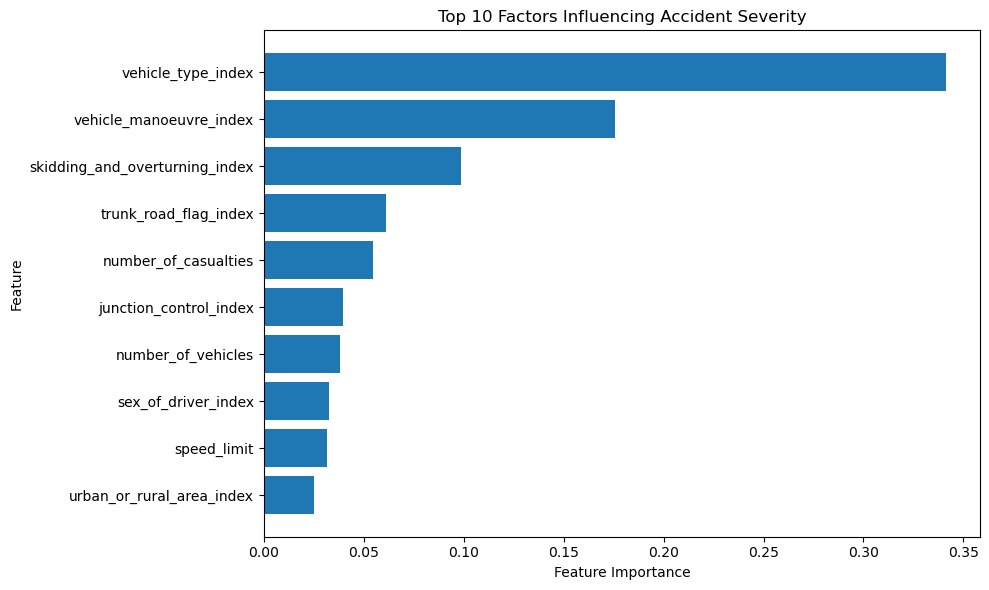

In [139]:
import matplotlib.pyplot as plt

top_features = feature_importance_sorted[:10]

features = [x[0] for x in top_features]
values = [x[1] for x in top_features]

plt.figure(figsize=(10, 6))
plt.barh(features[::-1], values[::-1])
plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Top 10 Factors Influencing Accident Severity")
plt.tight_layout()
plt.show()

In [140]:
collision_vehicle.groupBy(
    "time_period",
    "severity_label"
).count().orderBy(
    "time_period",
    "severity_label"
).show()

+-----------+--------------+-----+
|time_period|severity_label|count|
+-----------+--------------+-----+
|  Afternoon|         Fatal|  813|
|  Afternoon|       Serious|15467|
|  Afternoon|        Slight|48687|
|    Evening|         Fatal|  588|
|    Evening|       Serious|11047|
|    Evening|        Slight|34374|
|    Morning|         Fatal|  612|
|    Morning|       Serious|11390|
|    Morning|        Slight|38775|
|      Night|         Fatal|  547|
|      Night|       Serious| 6044|
|      Night|        Slight|15600|
+-----------+--------------+-----+



In [141]:
from pyspark.sql.functions import round

time_severity = collision_vehicle.groupBy(
    "time_period",
    "severity_label"
).count()

time_totals = collision_vehicle.groupBy(
    "time_period"
).count().withColumnRenamed(
    "count",
    "total_accidents"
)

time_severity = time_severity.join(
    time_totals,
    "time_period"
).withColumn(
    "percentage",
    round(
        col("count") * 100 / col("total_accidents"),
        2
    )
)

time_severity.orderBy(
    "time_period",
    "severity_label"
).show()

+-----------+--------------+-----+---------------+----------+
|time_period|severity_label|count|total_accidents|percentage|
+-----------+--------------+-----+---------------+----------+
|  Afternoon|         Fatal|  813|          64967|      1.25|
|  Afternoon|       Serious|15467|          64967|     23.81|
|  Afternoon|        Slight|48687|          64967|     74.94|
|    Evening|         Fatal|  588|          46009|      1.28|
|    Evening|       Serious|11047|          46009|     24.01|
|    Evening|        Slight|34374|          46009|     74.71|
|    Morning|         Fatal|  612|          50777|      1.21|
|    Morning|       Serious|11390|          50777|     22.43|
|    Morning|        Slight|38775|          50777|     76.36|
|      Night|         Fatal|  547|          22191|      2.46|
|      Night|       Serious| 6044|          22191|     27.24|
|      Night|        Slight|15600|          22191|      70.3|
+-----------+--------------+-----+---------------+----------+



In [142]:
collision_vehicle.groupBy(
    "weather_conditions",
    "severity_label"
).count().orderBy(
    "weather_conditions",
    "severity_label"
).show()

+------------------+--------------+------+
|weather_conditions|severity_label| count|
+------------------+--------------+------+
|                 1|         Fatal|  2232|
|                 1|       Serious| 37111|
|                 1|        Slight|112911|
|                 2|         Fatal|   223|
|                 2|       Serious|  4245|
|                 2|        Slight| 13688|
|                 3|         Fatal|     3|
|                 3|       Serious|   121|
|                 3|        Slight|   301|
|                 4|         Fatal|    29|
|                 4|       Serious|   356|
|                 4|        Slight|   874|
|                 5|         Fatal|    19|
|                 5|       Serious|   361|
|                 5|        Slight|  1065|
|                 6|       Serious|     2|
|                 6|        Slight|    34|
|                 7|         Fatal|    17|
|                 7|       Serious|   158|
|                 7|        Slight|   390|
+----------

In [143]:
collision_vehicle.groupBy(
    "road_surface_conditions",
    "severity_label"
).count().orderBy(
    "road_surface_conditions",
    "severity_label"
).show()

+-----------------------+--------------+------+
|road_surface_conditions|severity_label| count|
+-----------------------+--------------+------+
|                   NULL|         Fatal|     4|
|                   NULL|       Serious|    99|
|                   NULL|        Slight|   965|
|                      1|         Fatal|  1942|
|                      1|       Serious| 33249|
|                      1|        Slight|102900|
|                      2|         Fatal|   580|
|                      2|       Serious|  9824|
|                      2|        Slight| 29482|
|                      3|         Fatal|     4|
|                      3|       Serious|    76|
|                      3|        Slight|   174|
|                      4|         Fatal|    25|
|                      4|       Serious|   447|
|                      4|        Slight|  1593|
|                      5|         Fatal|     5|
|                      5|       Serious|    64|
|                      5|        Slight|

In [144]:
collision_vehicle.groupBy(
    "speed_limit",
    "severity_label"
).count().orderBy(
    "speed_limit",
    "severity_label"
).show()

+-----------+--------------+-----+
|speed_limit|severity_label|count|
+-----------+--------------+-----+
|         20|         Fatal|  152|
|         20|       Serious| 7191|
|         20|        Slight|27139|
|         30|         Fatal|  677|
|         30|       Serious|20238|
|         30|        Slight|67556|
|         40|         Fatal|  286|
|         40|       Serious| 4122|
|         40|        Slight|12665|
|         50|         Fatal|  208|
|         50|       Serious| 2377|
|         50|        Slight| 6518|
|         60|         Fatal|  885|
|         60|       Serious| 7367|
|         60|        Slight|14471|
|         70|         Fatal|  352|
|         70|       Serious| 2653|
|         70|        Slight| 9087|
+-----------+--------------+-----+



In [145]:
collision_vehicle.groupBy(
    "driver_age_group",
    "severity_label"
).count().orderBy(
    "driver_age_group",
    "severity_label"
).show()

+----------------+--------------+-----+
|driver_age_group|severity_label|count|
+----------------+--------------+-----+
|           18-25|         Fatal|  389|
|           18-25|       Serious| 6706|
|           18-25|        Slight|19248|
|           26-40|         Fatal|  649|
|           26-40|       Serious|11683|
|           26-40|        Slight|38403|
|           41-60|         Fatal|  753|
|           41-60|       Serious|12091|
|           41-60|        Slight|35956|
|             61+|         Fatal|  596|
|             61+|       Serious| 7098|
|             61+|        Slight|16849|
|        Under 18|         Fatal|   57|
|        Under 18|       Serious| 1511|
|        Under 18|        Slight| 3694|
|         Unknown|         Fatal|  116|
|         Unknown|       Serious| 4859|
|         Unknown|        Slight|23286|
+----------------+--------------+-----+



In [146]:
age_severity = collision_vehicle.groupBy(
    "driver_age_group",
    "severity_label"
).count()

age_totals = collision_vehicle.groupBy(
    "driver_age_group"
).count().withColumnRenamed(
    "count",
    "total_accidents"
)

age_severity = age_severity.join(
    age_totals,
    "driver_age_group"
).withColumn(
    "percentage",
    round(
        col("count") * 100 / col("total_accidents"),
        2
    )
)

age_severity.orderBy(
    "driver_age_group",
    "severity_label"
).show()

+----------------+--------------+-----+---------------+----------+
|driver_age_group|severity_label|count|total_accidents|percentage|
+----------------+--------------+-----+---------------+----------+
|           18-25|         Fatal|  389|          26343|      1.48|
|           18-25|       Serious| 6706|          26343|     25.46|
|           18-25|        Slight|19248|          26343|     73.07|
|           26-40|         Fatal|  649|          50735|      1.28|
|           26-40|       Serious|11683|          50735|     23.03|
|           26-40|        Slight|38403|          50735|     75.69|
|           41-60|         Fatal|  753|          48800|      1.54|
|           41-60|       Serious|12091|          48800|     24.78|
|           41-60|        Slight|35956|          48800|     73.68|
|             61+|         Fatal|  596|          24543|      2.43|
|             61+|       Serious| 7098|          24543|     28.92|
|             61+|        Slight|16849|          24543|     68

In [147]:
severity_distribution = collision_vehicle.groupBy(
    "severity_label"
).count().orderBy(
    "count",
    ascending=False
)

severity_distribution.show()

+--------------+------+
|severity_label| count|
+--------------+------+
|        Slight|137436|
|       Serious| 43948|
|         Fatal|  2560|
+--------------+------+



In [148]:
time_severity = collision_vehicle.groupBy(
    "time_period",
    "severity_label"
).count().orderBy(
    "time_period",
    "severity_label"
)

time_severity.show()

+-----------+--------------+-----+
|time_period|severity_label|count|
+-----------+--------------+-----+
|  Afternoon|         Fatal|  813|
|  Afternoon|       Serious|15467|
|  Afternoon|        Slight|48687|
|    Evening|         Fatal|  588|
|    Evening|       Serious|11047|
|    Evening|        Slight|34374|
|    Morning|         Fatal|  612|
|    Morning|       Serious|11390|
|    Morning|        Slight|38775|
|      Night|         Fatal|  547|
|      Night|       Serious| 6044|
|      Night|        Slight|15600|
+-----------+--------------+-----+



In [151]:
print(spark.range(5).count())

5


In [152]:
severity_distribution.toPandas().to_csv(
    "severity_distribution.csv",
    index=False
)

print("severity_distribution.csv saved successfully")

C:\Users\aasth\anaconda3\envs\ds_env\lib\site-packages\pyspark\sql\pandas\conversion.py:348: UserWarning: toPandas attempted Arrow optimization because 'spark.sql.execution.arrow.pyspark.enabled' is set to true; however, failed by the reason below:
  [PACKAGE_NOT_INSTALLED] PyArrow >= 18.0.0 must be installed; however, it was not found.
Attempting non-optimization as 'spark.sql.execution.arrow.pyspark.fallback.enabled' is set to true.
  warn(msg)


severity_distribution.csv saved successfully


In [153]:
time_severity.toPandas().to_csv(
    "time_severity.csv",
    index=False
)

print("time_severity.csv saved successfully")

C:\Users\aasth\anaconda3\envs\ds_env\lib\site-packages\pyspark\sql\pandas\conversion.py:348: UserWarning: toPandas attempted Arrow optimization because 'spark.sql.execution.arrow.pyspark.enabled' is set to true; however, failed by the reason below:
  [PACKAGE_NOT_INSTALLED] PyArrow >= 18.0.0 must be installed; however, it was not found.
Attempting non-optimization as 'spark.sql.execution.arrow.pyspark.fallback.enabled' is set to true.
  warn(msg)


time_severity.csv saved successfully


In [154]:
predictions = rf_model.transform(test_prepared)

predictions.select(
    "label",
    "prediction"
).show(10)

+-----+----------+
|label|prediction|
+-----+----------+
|  1.0|       0.0|
|  0.0|       0.0|
|  0.0|       0.0|
|  0.0|       0.0|
|  0.0|       0.0|
|  0.0|       0.0|
|  0.0|       0.0|
|  0.0|       0.0|
|  1.0|       0.0|
|  0.0|       0.0|
+-----+----------+
only showing top 10 rows


In [155]:
prediction_results = predictions.select(
    "label",
    "prediction"
).withColumnRenamed(
    "label",
    "actual_severity"
).withColumnRenamed(
    "prediction",
    "predicted_severity"
)

prediction_results.show(10)

+---------------+------------------+
|actual_severity|predicted_severity|
+---------------+------------------+
|            1.0|               0.0|
|            0.0|               0.0|
|            0.0|               0.0|
|            0.0|               0.0|
|            0.0|               0.0|
|            0.0|               0.0|
|            0.0|               0.0|
|            0.0|               0.0|
|            1.0|               0.0|
|            0.0|               0.0|
+---------------+------------------+
only showing top 10 rows


In [156]:
prediction_results = predictions.select(
    "label",
    "prediction"
).withColumnRenamed(
    "label",
    "actual_severity"
).withColumnRenamed(
    "prediction",
    "predicted_severity"
)

prediction_results.toPandas().to_csv(
    "prediction_results.csv",
    index=False
)

print("prediction_results.csv saved successfully")

C:\Users\aasth\anaconda3\envs\ds_env\lib\site-packages\pyspark\sql\pandas\conversion.py:348: UserWarning: toPandas attempted Arrow optimization because 'spark.sql.execution.arrow.pyspark.enabled' is set to true; however, failed by the reason below:
  [PACKAGE_NOT_INSTALLED] PyArrow >= 18.0.0 must be installed; however, it was not found.
Attempting non-optimization as 'spark.sql.execution.arrow.pyspark.fallback.enabled' is set to true.
  warn(msg)


prediction_results.csv saved successfully


In [157]:
powerbi_data = collision_vehicle.select(
    "collision_index",
    "accident_date",
    "accident_month",
    "accident_day",
    "accident_hour",
    "time_period",
    "hour_category",
    "day_of_week",
    "weekend_flag",
    "latitude",
    "longitude",
    "severity_label",
    "number_of_vehicles",
    "number_of_casualties",
    "road_type",
    "speed_limit",
    "speed_category",
    "vehicle_type",
    "vehicle_manoeuvre",
    "skidding_and_overturning",
    "age_of_driver",
    "driver_age_group",
    "sex_of_driver",
    "weather_conditions",
    "road_surface_conditions",
    "light_conditions",
    "urban_or_rural_area",
    "junction_detail",
    "junction_control",
    "trunk_road_flag"
)

print("Power BI dataset created:")
print("Rows:", powerbi_data.count())
print("Columns:", len(powerbi_data.columns))

Power BI dataset created:
Rows: 183944
Columns: 30


In [158]:
powerbi_data.printSchema()

root
 |-- collision_index: string (nullable = true)
 |-- accident_date: date (nullable = true)
 |-- accident_month: integer (nullable = true)
 |-- accident_day: integer (nullable = true)
 |-- accident_hour: integer (nullable = true)
 |-- time_period: string (nullable = false)
 |-- hour_category: string (nullable = false)
 |-- day_of_week: integer (nullable = true)
 |-- weekend_flag: string (nullable = false)
 |-- latitude: double (nullable = true)
 |-- longitude: double (nullable = true)
 |-- severity_label: string (nullable = false)
 |-- number_of_vehicles: integer (nullable = true)
 |-- number_of_casualties: integer (nullable = true)
 |-- road_type: integer (nullable = true)
 |-- speed_limit: integer (nullable = true)
 |-- speed_category: string (nullable = false)
 |-- vehicle_type: integer (nullable = true)
 |-- vehicle_manoeuvre: integer (nullable = true)
 |-- skidding_and_overturning: integer (nullable = true)
 |-- age_of_driver: integer (nullable = true)
 |-- driver_age_group: st

In [159]:
powerbi_data.show(10, truncate=False)

+---------------+-------------+--------------+------------+-------------+-----------+-------------+-----------+------------+--------+---------+--------------+------------------+--------------------+---------+-----------+--------------+------------+-----------------+------------------------+-------------+----------------+-------------+------------------+-----------------------+----------------+-------------------+---------------+----------------+---------------+
|collision_index|accident_date|accident_month|accident_day|accident_hour|time_period|hour_category|day_of_week|weekend_flag|latitude|longitude|severity_label|number_of_vehicles|number_of_casualties|road_type|speed_limit|speed_category|vehicle_type|vehicle_manoeuvre|skidding_and_overturning|age_of_driver|driver_age_group|sex_of_driver|weather_conditions|road_surface_conditions|light_conditions|urban_or_rural_area|junction_detail|junction_control|trunk_road_flag|
+---------------+-------------+--------------+------------+---------

In [160]:
print("Total rows:", powerbi_data.count())

Total rows: 183944


In [162]:
powerbi_data_pd = powerbi_data.toPandas()

powerbi_data_pd.to_csv(
    "powerbi_accident_data.csv",
    index=False
)

print("Power BI dataset exported successfully")
print("Rows:", len(powerbi_data_pd))
print("Columns:", len(powerbi_data_pd.columns))

C:\Users\aasth\anaconda3\envs\ds_env\lib\site-packages\pyspark\sql\pandas\conversion.py:348: UserWarning: toPandas attempted Arrow optimization because 'spark.sql.execution.arrow.pyspark.enabled' is set to true; however, failed by the reason below:
  [PACKAGE_NOT_INSTALLED] PyArrow >= 18.0.0 must be installed; however, it was not found.
Attempting non-optimization as 'spark.sql.execution.arrow.pyspark.fallback.enabled' is set to true.
  warn(msg)


Power BI dataset exported successfully
Rows: 183944
Columns: 30


In [163]:
import os

print(os.path.abspath("powerbi_accident_data.csv"))

C:\Users\aasth\DataScience\powerbi_accident_data.csv
